In [1]:
import sys
from pathlib import Path
import cv2
import numpy as np

# Add project root to path for imports
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [4]:
"""Dataset access for the KITTI object-detection benchmark."""
from src.geometry.boxes import get_lidar_boxes
from src.preprocessing.bev import bev_projection
from src.targets.bev_targets import create_bev_targets


class KittiDataset:
    """Load aligned LiDAR, calibration, and optional label files."""

    VALID_SPLITS = {"training", "testing"}

    def __init__(self, root, split="training", load_images=False):
        self.root = Path(root)
        if split not in self.VALID_SPLITS:
            raise ValueError("split must be 'training' or 'testing'")
        self.split = split
        self.load_images = load_images

        split_dir = self.root / split
        self.velodyne_dir = split_dir / "velodyne"
        self.label_dir = split_dir / "label_2"
        self.calib_dir = split_dir / "calib"
        self.image_dir = split_dir / "image_2"

        if not self.velodyne_dir.is_dir():
            raise FileNotFoundError(f"LiDAR directory not found: {self.velodyne_dir}")
        if not self.calib_dir.is_dir():
            raise FileNotFoundError(f"calibration directory not found: {self.calib_dir}")
        if self.load_images and not self.image_dir.is_dir():
            raise FileNotFoundError(f"Image directory not found: {self.image_dir}")

        self.has_labels = self.label_dir.is_dir()
        self.sample_ids = sorted(path.stem for path in self.velodyne_dir.glob("*.bin"))

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        sample_id = self.sample_ids[idx]
        return {
            "id": sample_id,
            "points": self.load_velodyne(sample_id),
            "calib": self.load_calibration(sample_id),
            "labels": self.load_labels(sample_id) if self.has_labels else [],
            "image": self.load_image(sample_id)
        }

    def load_image(self, sample_id):
        if not self.load_images:
            return None
        
        path = self.image_dir / f"{sample_id}.png"
        image = cv2.imread(path)

        if image is None:
            raise ValueError(f"Failed to decode camera image: {path}")

        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        return rgb_image

    def load_velodyne(self, sample_id):
        path = self.velodyne_dir / f"{sample_id}.bin"
        raw = np.fromfile(path, dtype=np.float32)
        if raw.size % 4:
            raise ValueError(f"invalid LiDAR file (float count is not divisible by 4): {path}")
        return raw.reshape(-1, 4)

    def load_calibration(self, sample_id):
        path = self.calib_dir / f"{sample_id}.txt"
        values = {}
        with path.open(encoding="utf-8") as file:
            for line_number, line in enumerate(file, start=1):
                line = line.strip()
                if not line:
                    continue
                if ":" not in line:
                    raise ValueError(f"invalid calibration line {line_number} in {path}")
                key, raw_values = line.split(":", maxsplit=1)
                values[key] = np.fromstring(raw_values, sep=" ", dtype=np.float32)

        expected = {"P2": 12, "R0_rect": 9, "Tr_velo_to_cam": 12}
        for key, count in expected.items():
            if key not in values:
                raise ValueError(f"missing calibration key {key!r} in {path}")
            if values[key].size != count or not np.isfinite(values[key]).all():
                raise ValueError(f"invalid calibration value {key!r} in {path}")

        return {
            "p2": values["P2"].reshape(3, 4),
            "r0_rect": values["R0_rect"].reshape(3, 3),
            "tr_velo_to_cam": values["Tr_velo_to_cam"].reshape(3, 4),
        }

    def load_labels(self, sample_id):
        if not self.has_labels:
            return []

        path = self.label_dir / f"{sample_id}.txt"
        objects = []
        with path.open(encoding="utf-8") as file:
            for line_number, line in enumerate(file, start=1):
                fields = line.split()
                if not fields:
                    continue
                if len(fields) != 15:
                    raise ValueError(
                        f"expected 15 label fields on line {line_number} in {path}, "
                        f"got {len(fields)}"
                    )
                try:
                    obj = {
                        "type": fields[0],
                        "truncated": float(fields[1]),
                        "occluded": int(fields[2]),
                        "alpha": float(fields[3]),
                        "bbox": np.asarray(fields[4:8], dtype=np.float32),
                        "dimensions": np.asarray(fields[8:11], dtype=np.float32),
                        "location": np.asarray(fields[11:14], dtype=np.float32),
                        "rotation_y": float(fields[14]),
                    }
                except ValueError as exc:
                    raise ValueError(f"invalid label values on line {line_number} in {path}") from exc
                numeric = np.concatenate((obj["bbox"], obj["dimensions"], obj["location"]))
                if not np.isfinite(numeric).all() or not np.isfinite(obj["rotation_y"]):
                    raise ValueError(f"non-finite label values on line {line_number} in {path}")
                objects.append(obj)
        return objects


    def get_training_sample(self, idx):
        if not self.has_labels:
            raise ValueError(f"split {self.split!r} has no labels for training targets")
        sample = self[idx]
        bev = bev_projection(sample["points"])
        boxes = get_lidar_boxes(sample["labels"], sample["calib"])
        return bev, create_bev_targets(boxes)


Sample ID: 006000
LiDAR: (122979, 4)
Image: (375, 1242, 3)
Image dtype: uint8
Calibration: dict_keys(['p2', 'r0_rect', 'tr_velo_to_cam'])
Labels: 5


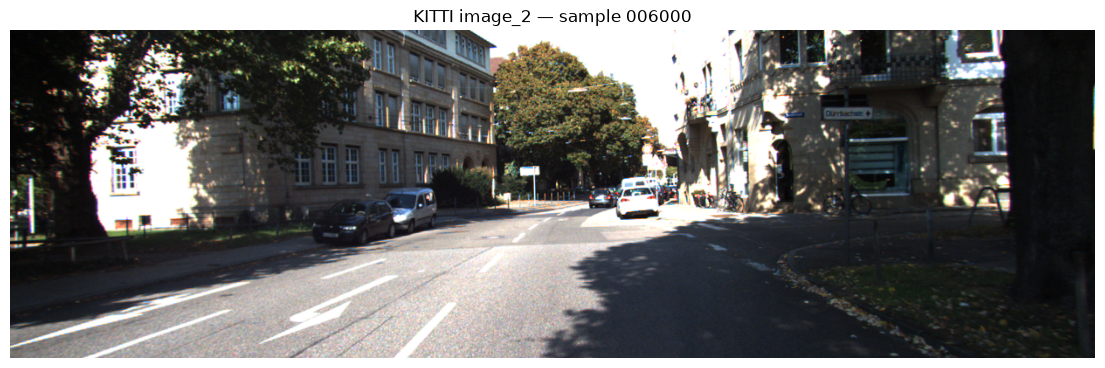

In [7]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))



dataset = KittiDataset(root="../data/KITTI",load_images=True)

sample = dataset[6000]

print("Sample ID:", sample["id"])
print("LiDAR:", sample["points"].shape)
print("Image:", sample["image"].shape)
print("Image dtype:", sample["image"].dtype)
print("Calibration:", sample["calib"].keys())
print("Labels:", len(sample["labels"]))

assert sample["points"].ndim == 2
assert sample["points"].shape[1] == 4

assert sample["image"].ndim == 3
assert sample["image"].shape[2] == 3
assert sample["image"].dtype.name == "uint8"

plt.figure(figsize=(14, 5))
plt.imshow(sample["image"])
plt.title(f"KITTI image_2 — sample {sample['id']}")
plt.axis("off")
plt.show()